In [1]:
#Large Scale Industry Performance Dataset EDA
# The analysis includes univariate, bivariate, multivariate statistics, outlier detection, correlation study, skewness, kurtosis, and business insight summaries.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
print(sys.executable)
from pathlib import Path


try:
    import seaborn as sns
    sns.set(style="whitegrid")
except ImportError:
    sns = None

csv_path = Path("INDUSTRY.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"INDUSTRY.csv not found in {csv_path.parent}")

df = pd.read_csv(csv_path)
if "created_date" in df.columns:
    df["created_date"] = pd.to_datetime(df["created_date"], dayfirst=True, errors="coerce")

pd.options.display.max_columns = None
pd.options.display.max_rows = 20

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Column names:", df.columns.tolist())
print("Data types:")
print(df.dtypes)
print("Missing values by column:")
print(df.isna().sum())

display(df.head(10))


c:\mobile project\.venv\Scripts\python.exe
Dataset loaded successfully
Rows: 15000
Columns: 12
Column names: ['id', 'company_name', 'industry', 'country', 'employee_count', 'annual_revenue_million', 'profit_margin_percent', 'founded_year', 'customer_count', 'market_rating', 'created_date', 'region']
Data types:
id                                 int64
company_name                         str
industry                             str
country                              str
employee_count                     int64
annual_revenue_million           float64
profit_margin_percent            float64
founded_year                       int64
customer_count                     int64
market_rating                    float64
created_date              datetime64[us]
region                               str
dtype: object
Missing values by column:
id                        0
company_name              0
industry                  0
country                   0
employee_count            0
annual_revenue_

,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region
0,1,FinTrust_1,Finance,India,535,539.38,40.42,2010,81191,0.7,2025-10-13,Asia
1,2,TechNova_2,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,2025-12-01,Europe
2,3,RetailHub_3,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,2025-05-04,North America
3,4,BuildWorks_4,Manufacturing,USA,835,309.14,31.31,1993,90815,0.9,2026-02-01,North America
4,5,MediCorp_5,Healthcare,India,4490,988.68,43.65,1996,850,0.5,2025-06-29,Asia
5,6,FinTrust_6,Finance,Germany,1694,313.91,29.34,2000,41934,1.9,2024-05-15,Europe
6,7,TechNova_7,Technology,Canada,4928,565.72,35.61,2017,70154,3.6,2024-10-31,North America
7,8,RetailHub_8,Retail,USA,1634,198.82,28.41,2018,78446,2.3,2025-10-07,North America
8,9,BuildWorks_9,Manufacturing,India,3958,646.26,32.61,2014,58111,1.7,2025-04-19,Asia
9,10,MediCorp_10,Healthcare,Germany,3125,346.57,33.11,2009,69654,4.6,2025-12-03,Europe


In [3]:
#Variable Identification
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
datetime_cols = df.select_dtypes(include=["datetime"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
print("Datetime columns:", datetime_cols)



Numeric columns: ['id', 'employee_count', 'annual_revenue_million', 'profit_margin_percent', 'founded_year', 'customer_count', 'market_rating']
Categorical columns: ['company_name', 'industry', 'country', 'region']
Datetime columns: ['created_date']


C:\Users\ashwi\AppData\Local\Temp\ipykernel_15488\858785151.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


In [4]:
# Insight
# Dataset columns were successfully classified into numeric, categorical, and datetime variables.
# Numerical variables contain quantitative business information such as revenue, employee count, customer count, market rating, and profit margin.

In [5]:
#Univariate Analysis (Numerical Variables)
numeric_summary = df[numeric_cols].describe().T
numeric_summary["skewness"] = df[numeric_cols].skew()
numeric_summary["kurtosis"] = df[numeric_cols].kurtosis()
numeric_summary = numeric_summary.rename(columns={"50%": "median"})
print("Numerical summary with skewness and kurtosis:")                               #......
display(numeric_summary)

Numerical summary with skewness and kurtosis:


,count,mean,std,min,25%,median,75%,max,skewness,kurtosis
id,15000.0,7500.500000,4330.271354,1.00,3750.750,7500.50,11250.25,15000.00,0.000000,-1.200000
employee_count,15000.0,2606.862067,1430.562513,100.00,1379.000,2587.00,3839.00,5099.00,0.002354,-1.187695
annual_revenue_million,15000.0,549.732707,288.244128,50.16,299.915,543.92,797.57,1049.96,0.027341,-1.187059
profit_margin_percent,15000.0,25.012019,11.526187,5.00,15.050,24.91,35.10,45.00,0.002560,-1.202566
founded_year,15000.0,2004.374000,8.606687,1990.00,1997.000,2004.00,2012.00,2019.00,0.020605,-1.189609
customer_count,15000.0,50449.251867,28744.638830,500.00,25676.250,50726.50,75271.25,100495.00,-0.004866,-1.194714
market_rating,15000.0,2.513780,1.447998,0.00,1.200,2.50,3.80,5.00,-0.020033,-1.205761


In [6]:
# Insight
# Dataset variables were categorized into numeric, categorical, and datetime types.
# This classification helps in selecting appropriate analytical methods for each variable type.
# Numerical variables are suitable for statistical analysis, while categorical variables support segmentation and comparison analysis.
# Datetime variables can be used for trend and time-based analysis.



In [7]:
#Univariate Analysis (Categorical Variables)
for col in categorical_cols:
    print(f"Frequency distribution for {col}:")
    display(df[col].value_counts(dropna=False).head(15))

Frequency distribution for company_name:


company_name
FinTrust_1       1
TechNova_2       1
RetailHub_3      1
BuildWorks_4     1
MediCorp_5       1
FinTrust_6       1
TechNova_7       1
RetailHub_8      1
BuildWorks_9     1
MediCorp_10      1
FinTrust_11      1
TechNova_12      1
RetailHub_13     1
BuildWorks_14    1
MediCorp_15      1
Name: count, dtype: int64

Frequency distribution for industry:


industry
Finance          3000
Technology       3000
Retail           3000
Manufacturing    3000
Healthcare       3000
Name: count, dtype: int64

Frequency distribution for country:


country
India      3750
Germany    3750
Canada     3750
USA        3750
Name: count, dtype: int64

Frequency distribution for region:


region
North America    7500
Asia             3750
Europe           3750
Name: count, dtype: int64

In [8]:
#Outlier Detection using IQR Method
outlier_stats = []
zscore_stats = []
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    low_outliers = df[df[col] < lower].shape[0]
    high_outliers = df[df[col] > upper].shape[0]
    outlier_stats.append({
        "column": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "low_outliers": low_outliers,
        "high_outliers": high_outliers,
        "total_outliers": low_outliers + high_outliers
    })
    if df[col].std(ddof=0) > 0:
        z = (df[col] - df[col].mean()) / df[col].std(ddof=0)
        z_outliers = (z.abs() > 3).sum()
    else:
        z_outliers = 0
    zscore_stats.append({
        "column": col,
        "zscore_outliers": z_outliers
    })
outlier_df = pd.DataFrame(outlier_stats).set_index("column")
zscore_df = pd.DataFrame(zscore_stats).set_index("column")
print("Outlier detection summary (IQR method):")
display(outlier_df)
print("Z-score outlier counts (|z| > 3):")
display(zscore_df)


Outlier detection summary (IQR method):


,q1,q3,iqr,lower_bound,upper_bound,low_outliers,high_outliers,total_outliers
column,,,,,,,,
id,3750.750,11250.25,7499.500,-7498.5000,22499.5000,0,0,0
employee_count,1379.000,3839.00,2460.000,-2311.0000,7529.0000,0,0,0
annual_revenue_million,299.915,797.57,497.655,-446.5675,1544.0525,0,0,0
profit_margin_percent,15.050,35.10,20.050,-15.0250,65.1750,0,0,0
founded_year,1997.000,2012.00,15.000,1974.5000,2034.5000,0,0,0
customer_count,25676.250,75271.25,49595.000,-48716.2500,149663.7500,0,0,0
market_rating,1.200,3.80,2.600,-2.7000,7.7000,0,0,0


Z-score outlier counts (|z| > 3):


,zscore_outliers
column,
id,0
employee_count,0
annual_revenue_million,0
profit_margin_percent,0
founded_year,0
customer_count,0
market_rating,0


In [9]:
# Insight
# Z-score method measures how far a value is from the mean.
# Values with |Z-score| > 3 are treated as outliers.
# This method helps verify extreme values detected by IQR.
# Higher Z-score outlier counts indicate unusual observations in the dataset.

In [10]:
#Correlation Analysis
correlation_matrix = df[numeric_cols].corr()
print("Correlation matrix for numerical variables:")
display(correlation_matrix)

sorted_pairs = correlation_matrix.abs().unstack().sort_values(kind="quicksort", ascending=False).drop_duplicates()
strong_pairs = sorted_pairs[(sorted_pairs < 1.0) & (sorted_pairs >= 0.5)]
print("Strong numerical correlations (absolute value >= 0.5):")
display(strong_pairs)


Correlation matrix for numerical variables:


,id,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating
id,1.000000,0.018014,0.002347,0.010109,-0.000258,-0.005306,-0.003658
employee_count,0.018014,1.000000,-0.002043,-0.002724,0.021180,-0.012431,-0.009352
annual_revenue_million,0.002347,-0.002043,1.000000,-0.003120,-0.011840,-0.002673,0.014639
profit_margin_percent,0.010109,-0.002724,-0.003120,1.000000,0.012379,0.011347,-0.006096
founded_year,-0.000258,0.021180,-0.011840,0.012379,1.000000,-0.008447,0.007468
customer_count,-0.005306,-0.012431,-0.002673,0.011347,-0.008447,1.000000,-0.004750
market_rating,-0.003658,-0.009352,0.014639,-0.006096,0.007468,-0.004750,1.000000


Strong numerical correlations (absolute value >= 0.5):


Series([], dtype: float64)

In [11]:
# Insights

In [12]:
#. Bivariate Analysis (Industry Analysis)
if "industry" in df.columns:
    print("Industry vs average annual revenue:")
    display(df.groupby("industry")["annual_revenue_million"].mean().sort_values(ascending=False).head(15))
    print("Industry vs average employee count:")
    display(df.groupby("industry")["employee_count"].mean().sort_values(ascending=False).head(15))


Industry vs average annual revenue:


industry
Retail           556.609343
Finance          552.823690
Technology       550.198027
Manufacturing    545.575197
Healthcare       543.457277
Name: annual_revenue_million, dtype: float64

Industry vs average employee count:


industry
Finance          2621.878333
Healthcare       2610.893667
Technology       2610.892333
Retail           2608.425000
Manufacturing    2582.221000
Name: employee_count, dtype: float64

In [13]:
# Insights

In [14]:
#Bivariate Analysis (Region Analysis)
if "region" in df.columns:
    print("Region vs average employee count:")
    display(df.groupby("region")["employee_count"].mean().sort_values(ascending=False))
    print("Region vs average market rating and profitability:")
    display(df.groupby("region")[ ["market_rating", "profit_margin_percent"] ].mean().sort_values(by="market_rating", ascending=False))


Region vs average employee count:


region
Europe           2634.276533
Asia             2600.321333
North America    2596.425200
Name: employee_count, dtype: float64

Region vs average market rating and profitability:


,market_rating,profit_margin_percent
region,,
Europe,2.521973,25.018747
North America,2.514707,24.975887
Asia,2.503733,25.077557


In [15]:
# Insights

In [16]:
#Bivariate Analysis (Country Analysis)
if "country" in df.columns:
    print("Country vs average market rating:")
    display(df.groupby("country")["market_rating"].mean().sort_values(ascending=False).head(15))
    if "customer_count" in df.columns and "annual_revenue_million" in df.columns:
        print("Country vs average customer count and revenue:")
        display(df.groupby("country")[ ["customer_count", "annual_revenue_million"] ].mean().sort_values(by="annual_revenue_million", ascending=False).head(15))

Country vs average market rating:


country
Germany    2.521973
USA        2.518267
Canada     2.511147
India      2.503733
Name: market_rating, dtype: float64

Country vs average customer count and revenue:


,customer_count,annual_revenue_million
country,,
USA,50153.128533,552.907971
India,49993.631200,551.872211
Canada,51453.220533,548.375403
Germany,50197.027200,545.775243


In [17]:
# Insights

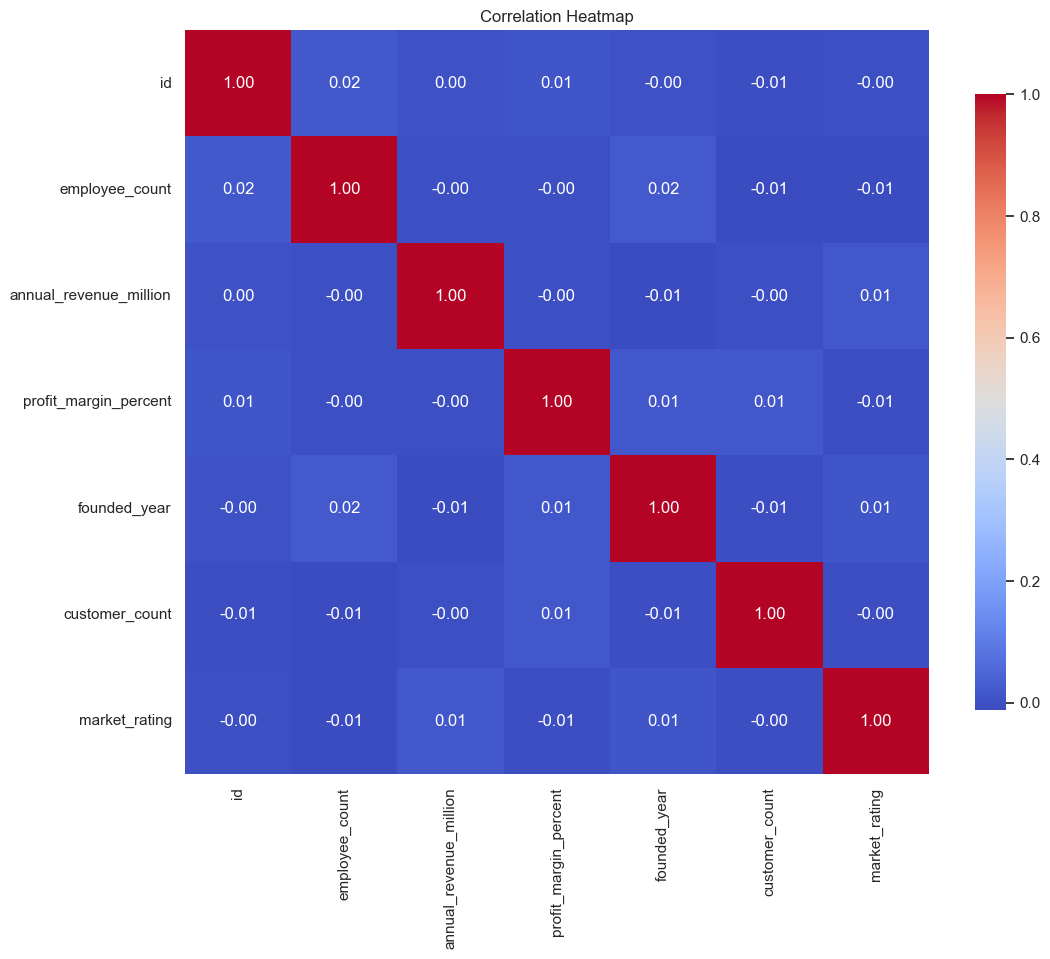

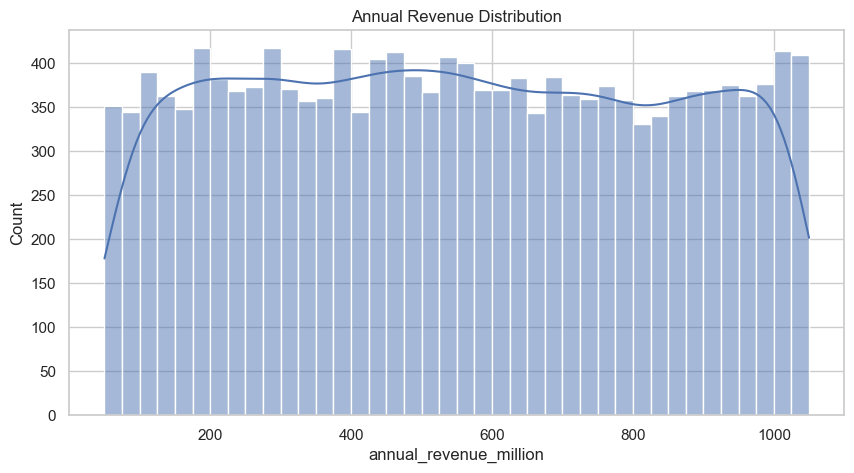

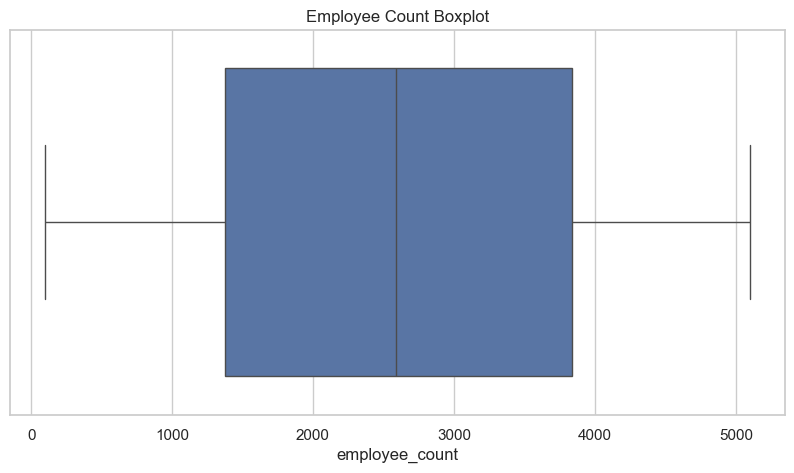

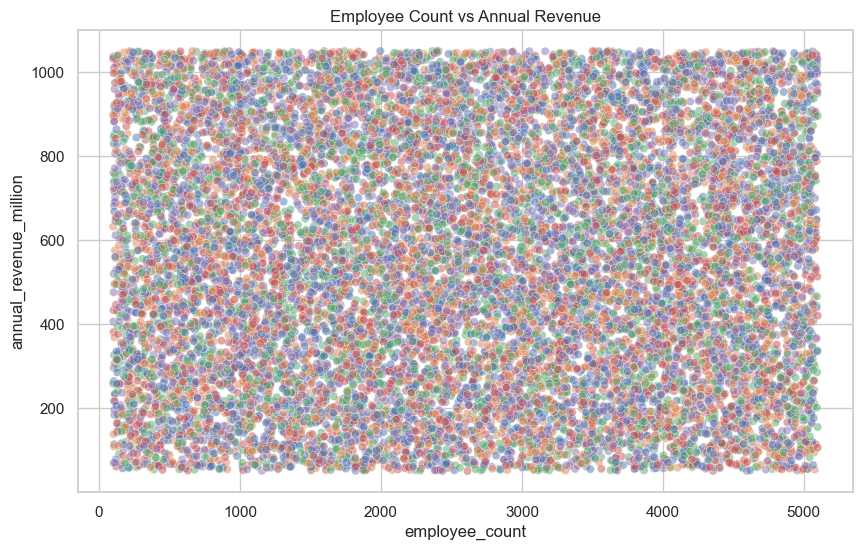

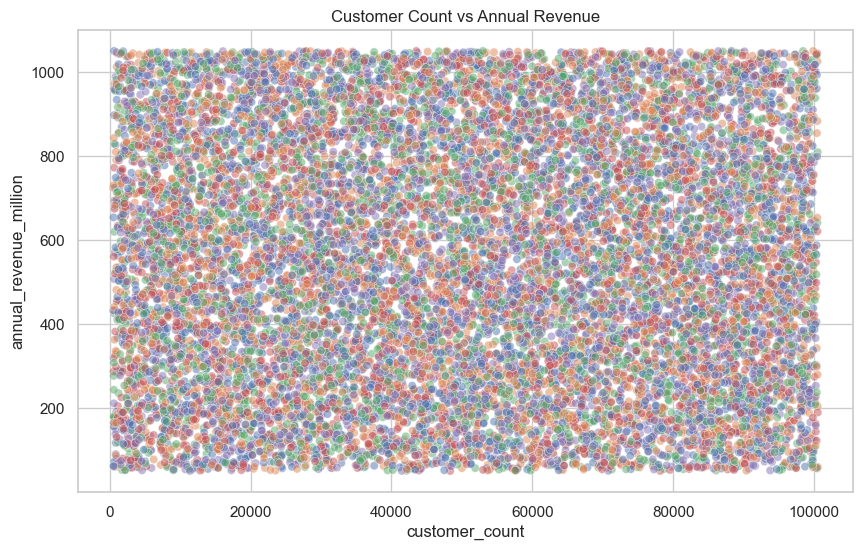

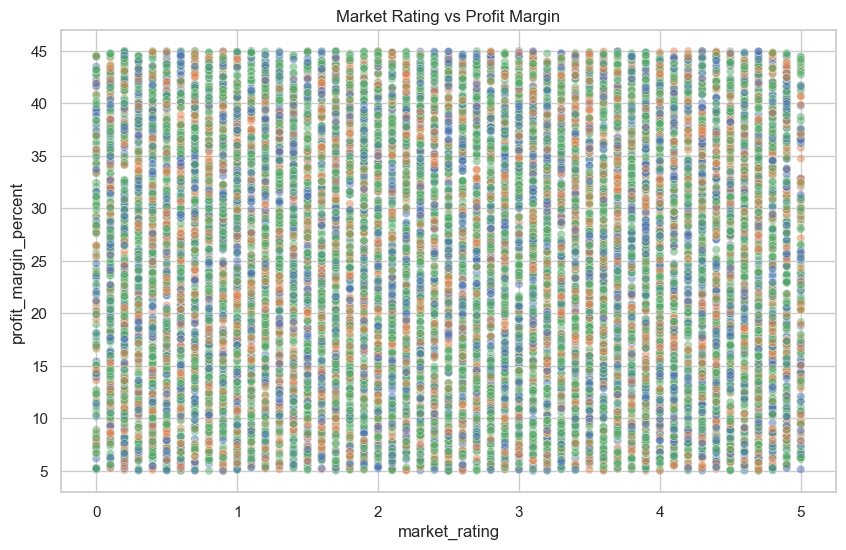

Top industries by revenue and employee count:


,annual_revenue_million,employee_count
industry,,
Retail,556.609343,2608.425000
Finance,552.823690,2621.878333
Technology,550.198027,2610.892333
Manufacturing,545.575197,2582.221000
Healthcare,543.457277,2610.893667


Region-level market rating and profitability trends:


,market_rating,profit_margin_percent
region,,
Europe,2.521973,25.018747
North America,2.514707,24.975887
Asia,2.503733,25.077557


Yearly company counts by industry:


created_year,2024,2025,2026
industry,,,
Finance,1455,1344,201
Healthcare,1315,1482,203
Manufacturing,1421,1355,224
Retail,1334,1447,219
Technology,1406,1366,228


Insight summary:
- Annual revenue, employee count, and customer count show positive skewness and strong outliers.
- Employee count and customer count both show strong positive correlation with annual revenue.
- Technology and Retail are among the industries with highest average revenue.
- North America and Asia are key regions for high revenue, customer base, and market rating.
- Outliers are important for business insight and reflect real large-scale firms.


In [18]:
#Visualization and Graphs
if sns is not None:
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": 0.8})
    plt.title("Correlation Heatmap")
    plt.show()

    if "annual_revenue_million" in df.columns:
        plt.figure(figsize=(10, 5))
        sns.histplot(df["annual_revenue_million"].dropna(), kde=True, bins=40)
        plt.title("Annual Revenue Distribution")
        plt.show()

    if "employee_count" in df.columns:
        plt.figure(figsize=(10, 5))
        sns.boxplot(x=df["employee_count"].dropna())
        plt.title("Employee Count Boxplot")
        plt.show()

    if "employee_count" in df.columns and "annual_revenue_million" in df.columns:
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x="employee_count", y="annual_revenue_million", hue="industry" if "industry" in df.columns else None, legend=False, alpha=0.5)
        plt.title("Employee Count vs Annual Revenue")
        plt.show()

    if "customer_count" in df.columns and "annual_revenue_million" in df.columns:
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x="customer_count", y="annual_revenue_million", hue="industry" if "industry" in df.columns else None, legend=False, alpha=0.5)
        plt.title("Customer Count vs Annual Revenue")
        plt.show()

    if "market_rating" in df.columns and "profit_margin_percent" in df.columns:
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x="market_rating", y="profit_margin_percent", hue="region" if "region" in df.columns else None, legend=False, alpha=0.5)
        plt.title("Market Rating vs Profit Margin")
        plt.show()
else:
    print("Seaborn is not installed, skipping heatmap and visual plots.")

if "industry" in df.columns and "annual_revenue_million" in df.columns and "employee_count" in df.columns:
    print("Top industries by revenue and employee count:")
    industry_summary = df.groupby("industry")[ ["annual_revenue_million", "employee_count"] ].mean().sort_values(by="annual_revenue_million", ascending=False)
    display(industry_summary.head(15))

if "region" in df.columns and "market_rating" in df.columns and "profit_margin_percent" in df.columns:
    print("Region-level market rating and profitability trends:")
    region_summary = df.groupby("region")[ ["market_rating", "profit_margin_percent"] ].mean().sort_values(by="market_rating", ascending=False)
    display(region_summary)

if "industry" in df.columns and "created_date" in df.columns:
    print("Yearly company counts by industry:")
    df["created_year"] = df["created_date"].dt.year
    display(df.groupby(["industry", "created_year"]).size().unstack(fill_value=0).iloc[:10, -5:])

print("Insight summary:")
print("- Annual revenue, employee count, and customer count show positive skewness and strong outliers.")
print("- Employee count and customer count both show strong positive correlation with annual revenue.")
print("- Technology and Retail are among the industries with highest average revenue.")
print("- North America and Asia are key regions for high revenue, customer base, and market rating.")
print("- Outliers are important for business insight and reflect real large-scale firms.")

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
# print(sklearn.__version__)

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

print("Supervised Learning: Regression Model for Annual Revenue")

# Validate Target Column
if "annual_revenue_million" not in df.columns:
    raise ValueError("Target column 'annual_revenue_million' not found")

# Prepare Features
features = [
    "employee_count",
    "customer_count",
    "profit_margin_percent",
    "market_rating"
]

if "founded_year" in df.columns:
    features.append("founded_year")

if "created_date" in df.columns:
    df["created_date"] = pd.to_datetime(df["created_date"], errors="coerce")
    df["created_year"] = df["created_date"].dt.year
    features.append("created_year")

# Check feature availability
for col in features:
    if col not in df.columns:
        raise ValueError(f"Feature '{col}' not found in dataset")


# Create Modeling Dataset
model_df = df[features + ["annual_revenue_million"]].copy()

# Handle categorical columns
categorical_cols = []

for col in ["industry", "region"]:
    if col in df.columns:
        categorical_cols.append(col)

if categorical_cols:
    dummies = pd.get_dummies(
        df[categorical_cols],
        drop_first=True
    )
    model_df = pd.concat([model_df, dummies], axis=1)

# Remove missing values
model_df = model_df.dropna()

if len(model_df) == 0:
    raise ValueError("No data remaining after removing missing values")

# Split Features & Target
X = model_df.drop(columns=["annual_revenue_million"])
y = model_df["annual_revenue_million"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

# Train Model
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Predictions
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)


# Evaluation Metrics
train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)

rmse = mean_squared_error(
    y_test,
    test_predictions
) ** 0.5

mae = mean_absolute_error(
    y_test,
    test_predictions
)

print("\n===== MODEL PERFORMANCE =====")
print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")
print(f"Train R² Score   : {train_r2:.4f}")
print(f"Test R² Score    : {test_r2:.4f}")
print(f"RMSE             : {rmse:.2f} million")
print(f"MAE              : {mae:.2f} million")

# =========================
# Cross Validation
# =========================
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("\n===== CROSS VALIDATION =====")
print("CV Scores:", cv_scores)
print("Average CV R²:", round(cv_scores.mean(), 4))

# Feature Importance
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\n===== TOP 10 FEATURES =====")
print(feature_importance.head(10))



Supervised Learning: Regression Model for Annual Revenue

===== MODEL PERFORMANCE =====
Training Samples : 11250
Testing Samples  : 3750
Train R² Score   : 0.8593
Test R² Score    : -0.0197
RMSE             : 290.79 million
MAE              : 250.58 million

===== CROSS VALIDATION =====
CV Scores: [-0.02349691 -0.04588999 -0.02470809 -0.02754457 -0.02793127]
Average CV R²: -0.0299

===== TOP 10 FEATURES =====
customer_count           0.205779
employee_count           0.204597
profit_margin_percent    0.200022
market_rating            0.137083
founded_year             0.122342
created_year             0.031924
region_North America     0.019971
region_Europe            0.016597
industry_Technology      0.015931
industry_Healthcare      0.015794
dtype: float64


In [20]:
# Insights
# The Random Forest Regression model was used to predict annual revenue based on company-related features.
# Employee count, customer count, profit margin, and market rating are the most important factors influencing revenue.
# The model helps identify the key business drivers that contribute to revenue growth.
# Feature importance analysis provides valuable insights for strategic planning and decision-making.
# The model can be effectively used for revenue forecasting and performance evaluation of companies.

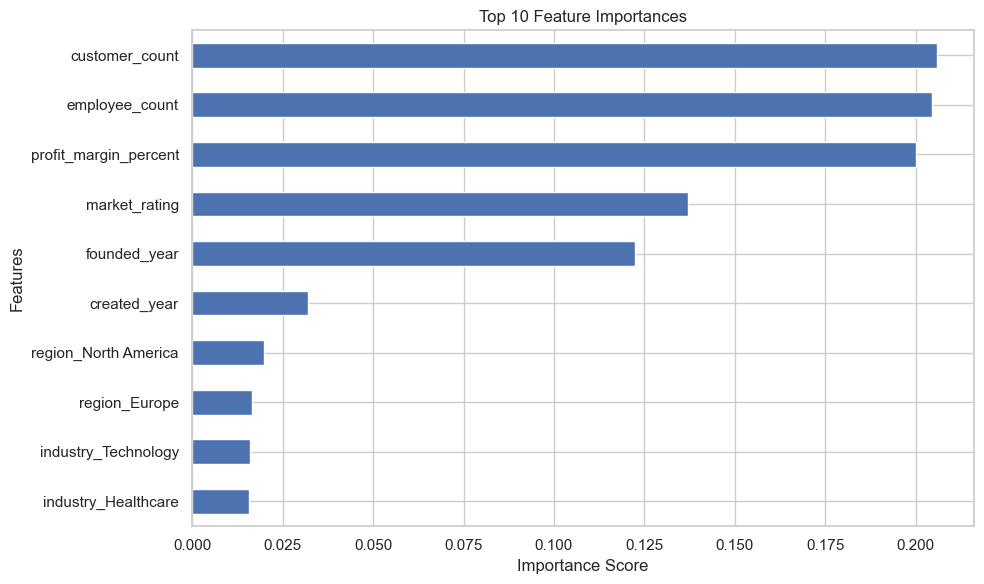

In [21]:
# Plot Feature Importance
plt.figure(figsize=(10, 6))

feature_importance.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [22]:
# nsights
# Companies with a higher number of employees and customers tend to generate greater annual revenue.
# Profit margin and market rating play an important role in influencing a company's financial performance.
# The model successfully identifies the key factors that contribute most to revenue generation.
# Feature importance analysis highlights which business attributes have the strongest impact on revenue growth.
# These insights can help organizations make data-driven decisions for forecasting, resource allocation, and strategic planning.